# CNN-LSTM Preprocessing, Training, and Evaluation Pipeline
### Data Preparation — Spatial Fold Assignment — Bayesian Hyperparameter Optimization — Spatial Bias Detection — Grad-CAM Interpretability

Implements the data preparation (Sections 4.2.1, 4.2.3, 4.2.5), dual-branch architecture and Bayesian hyperparameter optimization (Section 4.3), and spatial evaluation (Section 4.4) described in the thesis methodology, for the CNN-LSTM branch only -- the XGBoost-exclusive (4.2.4) and Mobile Monitoring (4.2.2) preprocessing sections, and Section 4.5's inference/map generation, are out of scope (model interpretability via Grad-CAM, Section 4.5.4, is included since it is CNN-LSTM-specific).

**The CNN's spatial branch reads morphology data exclusively from the Master GeoTIFF raster (`master_morphology_stack_500m.tif`) via `rasterio` -- never from a CSV.** Any coordinates or timestamps pulled from a CSV are used only to *locate* where to crop a patch from the raster or to supply the LSTM's temporal lag sequence; they never substitute for the raster's pixel values.

**Pipeline:**
1. Setup
2. Data preparation & feature engineering (Sections 4.2.1, 4.2.3, 4.2.5)
3. Spatial fold assignment (grouped by sensor location, Section 4.4.1's CNN-LSTM strategy)
4. Spatial k-fold Bayesian hyperparameter optimization (Section 4.3)
5. CV results & spatial bias detection (Section 4.4)
6. Final production model
7. Model interpretability via Grad-CAM (Section 4.5.4)
8. Summary

## 1. Setup

In [1]:
# Install required dependencies
!pip install -q geopandas pandas numpy rasterio shapely rasterstats scikit-learn scipy torch scikit-optimize libpysal esda matplotlib

In [2]:
# Import required libraries
# ---- General-purpose data handling ----
import os                                   # filesystem paths (finding sensor CSVs, building output paths)
import glob                                 # wildcard file pattern matching (locating per-sensor CSVs)
import warnings                             # suppress noisy library warnings for cleaner output
import numpy as np                          # numerical arrays and math operations
import pandas as pd                         # tabular data: DataFrames, CSV I/O, merges, groupby

# ---- Geospatial vector data ----
import geopandas as gpd                     # GeoDataFrames: reading/writing vector files, spatial joins, reprojection
from shapely.geometry import box            # build rectangular polygon geometries (grid cells, bounding boxes)

# ---- Geospatial raster data ----
import rasterio                             # read/write raster (GeoTIFF) files
from rasterio.windows import Window         # define a sub-region to read from a raster without loading the whole file
from rasterio.warp import calculate_default_transform, reproject  # reproject a raster between coordinate systems
from rasterio.enums import Resampling, MergeAlg  # resampling method enum (bilinear, nearest, ...) and rasterize merge strategy
from rasterio.mask import mask as rio_mask  # clip a raster to a vector polygon boundary
from rasterio.features import rasterize     # convert vector geometries into raster pixel values
from rasterstats import zonal_stats         # compute stats (mean/std) of raster values within vector polygons
from scipy.ndimage import uniform_filter    # moving-window average over a raster array (local neighborhood smoothing)

# ---- Preprocessing / classical ML ----
from sklearn.preprocessing import StandardScaler   # standardize features/target to zero mean, unit variance
from sklearn.model_selection import GroupKFold     # cross-validation splitting that keeps groups (sensors) together
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error  # regression evaluation metrics

# ---- Deep learning (CNN-LSTM model) ----
import torch                                # PyTorch tensor library
import torch.nn as nn                       # neural network layers/modules (Conv2d, LSTM, Linear, ...)
import torch.optim as optim                 # optimizers (Adam) used to update model weights during training
from torch.utils.data import Dataset, DataLoader  # custom dataset base class + batching/iteration during training

# ---- Bayesian hyperparameter optimization ----
from skopt import gp_minimize               # Gaussian-process-based Bayesian optimizer
from skopt.space import Real, Integer       # define continuous/integer hyperparameter search dimensions
from skopt.utils import use_named_args      # decorator mapping skopt's positional values to named kwargs

# ---- Spatial statistics (bias detection) ----
from libpysal.weights import KNN            # build a spatial weights matrix (K-nearest neighbors) for spatial statistics
from esda.moran import Moran, Moran_Local   # Global and Local (LISA) Moran's I spatial autocorrelation statistics

# ---- Visualization ----
import matplotlib.pyplot as plt             # plotting figures
import matplotlib.patches as mpatches       # custom legend patches for categorical map legends

# Suppress minor warnings for cleaner output
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
np.random.seed(42)

print("torch:", torch.__version__)

C:\Users\perez\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.12.0+cpu


## 2. Data Preparation & Feature Engineering

## Section 4.2.1 — General Data Preparation and Preprocessing
Shared preprocessing functions that build the spatial foundation (grid + morphology) consumed by both the XGBoost and CNN-LSTM branches.

### 4.2.1.1 Raw Data Ingestion, Sanitation, and CRS Alignment
Repairs invalid building geometries, hierarchically imputes missing street widths, and reprojects every vector layer from EPSG:4326 to the metric EPSG:32651 (UTM Zone 51N).

In [3]:
# ----------------------------------------------------------------------------
# 4.2.1.1 Raw Data Ingestion, Sanitation, and CRS Alignment
# ----------------------------------------------------------------------------

TARGET_CRS = "EPSG:32651"  # UTM Zone 51N (metric projection for the Philippines)

# Functional-class fallback widths (meters), used when both an explicit width and a lane
# count are unavailable for a street segment.
FUNCTIONAL_CLASS_WIDTHS = {
    "motorway": 20.0, "trunk": 16.0, "primary": 12.0, "secondary": 10.0,
    "tertiary": 8.0, "residential": 6.0, "unclassified": 5.0,
    "service": 4.0, "living_street": 4.0, "alley": 4.0, "track": 3.0,
}


def repair_geometries(gdf):
    """Fix self-intersections and open rings via a zero-distance buffer, mirroring the QGIS
    geometry-correction step applied to raw building footprints."""
    gdf = gdf.copy()
    invalid_mask = ~gdf.geometry.is_valid
    if invalid_mask.any():
        gdf.loc[invalid_mask, "geometry"] = gdf.loc[invalid_mask, "geometry"].buffer(0)
    return gdf


def impute_street_widths(streets_gdf, width_col="width", lanes_col="lanes", highway_col="highway",
                          lane_width_m=3.0, min_width=1.5, max_width=70.0,
                          functional_class_widths=None):
    """Hierarchical street-width imputation: explicit recorded width takes priority; if missing,
    lane count x `lane_width_m`; if both are absent, a functional-class fallback threshold is used.
    Result is clipped to [min_width, max_width] to filter anomalies while preserving legitimate layouts."""
    functional_class_widths = functional_class_widths or FUNCTIONAL_CLASS_WIDTHS
    gdf = streets_gdf.copy()

    explicit_width = pd.to_numeric(gdf[width_col], errors="coerce") if width_col in gdf else pd.Series(np.nan, index=gdf.index)
    lanes = pd.to_numeric(gdf[lanes_col], errors="coerce") if lanes_col in gdf else pd.Series(np.nan, index=gdf.index)

    calculated = explicit_width.fillna(lanes * lane_width_m)

    if highway_col in gdf.columns:
        # OSM sometimes stores multiple highway tags per way as a list; use the first as the primary class
        primary_class = gdf[highway_col].apply(lambda v: v[0] if isinstance(v, list) else v)
        calculated = calculated.fillna(primary_class.map(functional_class_widths))

    calculated = calculated.fillna(functional_class_widths["unclassified"])
    gdf["calculated_width"] = calculated.clip(lower=min_width, upper=max_width)
    return gdf


def reproject_layer(gdf, target_crs=TARGET_CRS):
    """Reproject a vector layer from EPSG:4326 (or any source CRS) to the metric target CRS; no-op if
    already aligned."""
    if gdf.crs is None:
        raise ValueError("Input GeoDataFrame has no CRS defined; cannot safely reproject.")
    return gdf.to_crs(target_crs) if str(gdf.crs) != str(target_crs) else gdf


def ingest_and_sanitize_vectors(buildings_path, streets_path, target_crs=TARGET_CRS, **impute_kwargs):
    """Ingest building footprints and road centerlines, repair geometries, impute street widths, and
    align both layers to the metric CRS."""
    buildings_gdf = repair_geometries(gpd.read_file(buildings_path))
    streets_gdf = impute_street_widths(gpd.read_file(streets_path), **impute_kwargs)

    buildings_gdf = reproject_layer(buildings_gdf, target_crs)
    streets_gdf = reproject_layer(streets_gdf, target_crs)
    return buildings_gdf, streets_gdf

### 4.2.1.2 Base Vector Grid Generation and Morphological Metric Extraction
Generates a uniform fishnet grid over the buffered sensor bounding box and extracts zonal building-height/NDVI statistics, building density, and canyon aspect ratio per cell.

In [4]:
# ----------------------------------------------------------------------------
# 4.2.1.2 Base Vector Grid Generation and Morphological Metric Extraction
# ----------------------------------------------------------------------------

def generate_vector_grid(sensors_gdf, cell_size_m=500, buffer_m=2000, crs=TARGET_CRS):
    """Build a uniform fishnet grid over the sensor bounding box, padded by `buffer_m` so edge sensors
    capture the morphology of their immediate perimeter neighborhoods."""
    sensors_gdf = reproject_layer(sensors_gdf, crs)
    minx, miny, maxx, maxy = sensors_gdf.total_bounds
    minx, miny, maxx, maxy = minx - buffer_m, miny - buffer_m, maxx + buffer_m, maxy + buffer_m

    cells = []
    row_index = 0
    y = miny
    while y < maxy:
        col_index = 0
        x = minx
        while x < maxx:
            cells.append({
                "geometry": box(x, y, x + cell_size_m, y + cell_size_m),
                "row_index": row_index,
                "col_index": col_index,
            })
            x += cell_size_m
            col_index += 1
        y += cell_size_m
        row_index += 1

    grid_gdf = gpd.GeoDataFrame(cells, crs=crs)
    grid_gdf.insert(0, "grid_id", range(1, len(grid_gdf) + 1))
    return grid_gdf


def compute_raster_zonal_stats(grid_gdf, raster_path, stats=("mean", "std"), prefix="bh"):
    """Zonal statistics (e.g. mean/std building height, mean NDVI) per grid cell from a raster layer."""
    results = zonal_stats(grid_gdf, raster_path, stats=list(stats), all_touched=True)
    grid_gdf = grid_gdf.copy()
    for stat in stats:
        grid_gdf[f"{prefix}_{stat}"] = [r[stat] for r in results]
    return grid_gdf


def compute_building_density(grid_gdf, buildings_gdf):
    """Fraction of each grid cell's area covered by building footprints."""
    buildings_gdf = reproject_layer(buildings_gdf, grid_gdf.crs)
    cell_area = grid_gdf.set_index("grid_id").geometry.area

    intersections = gpd.overlay(grid_gdf[["grid_id", "geometry"]], buildings_gdf[["geometry"]], how="intersection")
    covered_area = intersections.geometry.area.groupby(intersections["grid_id"]).sum()

    grid_gdf = grid_gdf.copy()
    grid_gdf["bldg_dens"] = (grid_gdf["grid_id"].map(covered_area).fillna(0) / grid_gdf["grid_id"].map(cell_area)).values
    return grid_gdf


def compute_canyon_aspect_ratio(grid_gdf, streets_gdf, height_raster_path, width_col="calculated_width"):
    """Buffer street segments by their calculated width, extract local building heights within the buffer,
    and derive the canyon aspect ratio (height / width) per grid cell."""
    streets_gdf = reproject_layer(streets_gdf, grid_gdf.crs)
    street_buffers = streets_gdf.copy()
    street_buffers["geometry"] = street_buffers.buffer(street_buffers[width_col] / 2.0)

    joined = gpd.sjoin(street_buffers, grid_gdf[["grid_id", "geometry"]], predicate="intersects", how="inner")

    aspect_ratios = {}
    for grid_id, group in joined.groupby("grid_id"):
        merged_buffer = group.geometry.unary_union
        buffer_gdf = gpd.GeoDataFrame({"geometry": [merged_buffer]}, crs=grid_gdf.crs)
        mean_height = zonal_stats(buffer_gdf, height_raster_path, stats=["mean"])[0]["mean"] or 0.0
        mean_width = group[width_col].mean()
        aspect_ratios[grid_id] = mean_height / mean_width if mean_width else np.nan

    grid_gdf = grid_gdf.copy()
    grid_gdf["aspect_ratio_mean"] = grid_gdf["grid_id"].map(aspect_ratios)
    return grid_gdf


def extract_morphological_metrics(grid_gdf, height_raster_path, ndvi_raster_path, buildings_gdf, streets_gdf):
    """Run the full grid -> morphology pipeline: building height stats, NDVI, building density, and
    canyon aspect ratio, transforming raw physical geometries into a numeric tabular profile per grid cell."""
    grid_gdf = compute_raster_zonal_stats(grid_gdf, height_raster_path, stats=("mean", "std"), prefix="bh")
    grid_gdf = compute_raster_zonal_stats(grid_gdf, ndvi_raster_path, stats=("mean",), prefix="ndvi")
    grid_gdf = compute_building_density(grid_gdf, buildings_gdf)
    grid_gdf = compute_canyon_aspect_ratio(grid_gdf, streets_gdf, height_raster_path)
    return grid_gdf

### 4.2.1.3 Spatiotemporal Alignment and Temporal Feature Engineering
Joins sensors to grid cells, broadcasts static morphology to every recorded hour, and engineers cyclical hour encodings, autoregressive lags, capped linear interpolation, and leakage-safe train-only scaling.

In [5]:
# ----------------------------------------------------------------------------
# 4.2.1.3 Spatiotemporal Alignment and Temporal Feature Engineering
# ----------------------------------------------------------------------------

def spatial_join_sensors_to_grid(sensors_gdf, grid_gdf):
    """Map each sensor location to its containing grid cell."""
    sensors_gdf = reproject_layer(sensors_gdf, grid_gdf.crs)
    joined = gpd.sjoin(sensors_gdf, grid_gdf[["grid_id", "geometry"]], predicate="within", how="left")
    return joined.drop(columns="index_right")


def merge_pm25_with_morphology(pm25_df, sensor_to_grid_df, grid_morphology_df, sensor_id_col="location_id"):
    """Broadcast static morphological metrics to every timestamp recorded at that sensor's grid cell,
    keyed on grid_id, without duplicating or losing rows."""
    id_to_grid = sensor_to_grid_df.set_index(sensor_id_col)["grid_id"]
    pm25_df = pm25_df.copy()
    pm25_df["grid_id"] = pm25_df[sensor_id_col].map(id_to_grid)

    morphology_cols = [c for c in grid_morphology_df.columns if c != "geometry"]
    return pm25_df.merge(grid_morphology_df[morphology_cols], on="grid_id", how="left")


def engineer_cyclical_time_features(df, timestamp_col="local_timestamp"):
    """Sine/cosine encode the hour of day so 23:00 and 00:00 are numerically adjacent."""
    df = df.copy()
    df[timestamp_col] = pd.to_datetime(df[timestamp_col])
    hour = df[timestamp_col].dt.hour
    df["sin_hour"] = np.sin(2 * np.pi * hour / 24)
    df["cos_hour"] = np.cos(2 * np.pi * hour / 24)
    return df


def engineer_lag_features(df, target_col="pm25_value", group_col="location_id",
                           timestamp_col="local_timestamp", lags=(1, 2, 3), rolling_window=None):
    """Chronologically group by sensor and create sliding-window lags (t-1, t-2, ...), plus an optional
    rolling mean/std, to capture pollutant autoregression."""
    df = df.sort_values([group_col, timestamp_col]).copy()
    grouped_target = df.groupby(group_col)[target_col]

    for lag in lags:
        df[f"{target_col}_t-{lag}"] = grouped_target.shift(lag)

    if rolling_window:
        df[f"{target_col}_roll_mean_{rolling_window}"] = grouped_target.transform(
            lambda s: s.shift(1).rolling(rolling_window).mean())
        df[f"{target_col}_roll_std_{rolling_window}"] = grouped_target.transform(
            lambda s: s.shift(1).rolling(rolling_window).std())
    return df


def interpolate_missing_readings(df, value_col="pm25_value", group_col="location_id",
                                  timestamp_col="local_timestamp", max_gap_hours=24):
    """Linearly interpolate missing readings per sensor, capped at `max_gap_hours` so extended sensor
    downtime is never fabricated."""
    df = df.sort_values([group_col, timestamp_col]).copy()
    df[value_col] = df.groupby(group_col)[value_col].transform(
        lambda s: s.interpolate(method="linear", limit=max_gap_hours, limit_direction="both"))
    return df


def fit_scaler_on_train_only(df, feature_cols, train_index):
    """Fit a StandardScaler exclusively on training-index rows to prevent leakage into the validation
    distribution, then transform the full frame."""
    scaler = StandardScaler().fit(df.loc[train_index, feature_cols])
    scaled_df = df.copy()
    scaled_df[feature_cols] = scaler.transform(df[feature_cols])
    return scaled_df, scaler


def apply_scaler(df, feature_cols, scaler):
    """Apply an already-fitted scaler (fit on training data) to a validation/test frame."""
    df = df.copy()
    df[feature_cols] = scaler.transform(df[feature_cols])
    return df

## Section 4.2.3 — Raster-Vector Integration Pipeline
### Resolution Harmonization and Reprojection
Aligns the 4m building-height raster and 10m NDVI raster to a common 10m x 10m footprint via reprojection, bilinear resampling, and boundary clipping/masking.

In [6]:
# ----------------------------------------------------------------------------
# 4.2.3 Raster-Vector Integration Pipeline
# Resolution Harmonization and Reprojection
# ----------------------------------------------------------------------------

def reproject_raster(src_path, dst_path, dst_crs=TARGET_CRS, resampling="bilinear"):
    """Reproject a raster (e.g. WGS 84 height/NDVI tiles) into the metric target CRS."""
    resampling_method = getattr(Resampling, resampling)
    with rasterio.open(src_path) as src:
        transform, width, height = calculate_default_transform(src.crs, dst_crs, src.width, src.height, *src.bounds)
        profile = src.profile.copy()
        profile.update(crs=dst_crs, transform=transform, width=width, height=height)

        with rasterio.open(dst_path, "w", **profile) as dst:
            for band in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, band), destination=rasterio.band(dst, band),
                    src_transform=src.transform, src_crs=src.crs,
                    dst_transform=transform, dst_crs=dst_crs, resampling=resampling_method,
                )
    return dst_path


def resample_raster_to_resolution(src_path, dst_path, target_resolution_m=10.0, resampling="bilinear"):
    """Resample a raster (e.g. the 4m building-height layer) to a target ground resolution, matching the
    10m NDVI grid. Bilinear interpolation is used (rather than nearest-neighbor) to preserve continuous
    height transitions across urban canyons."""
    resampling_method = getattr(Resampling, resampling)
    with rasterio.open(src_path) as src:
        new_width = max(1, round(src.width * src.res[0] / target_resolution_m))
        new_height = max(1, round(src.height * src.res[1] / target_resolution_m))

        data = src.read(out_shape=(src.count, new_height, new_width), resampling=resampling_method)
        new_transform = src.transform * src.transform.scale(src.width / new_width, src.height / new_height)

        profile = src.profile.copy()
        profile.update(transform=new_transform, width=new_width, height=new_height)

        with rasterio.open(dst_path, "w", **profile) as dst:
            dst.write(data)
    return dst_path


def clip_and_mask_to_boundary(src_path, boundary_gdf, dst_path):
    """Clip a raster to the study-area boundary and mask it to a shared NoData extent."""
    with rasterio.open(src_path) as src:
        boundary = boundary_gdf.to_crs(src.crs)
        out_image, out_transform = rio_mask(src, boundary.geometry, crop=True)
        profile = src.profile.copy()
        profile.update(height=out_image.shape[1], width=out_image.shape[2], transform=out_transform)

        with rasterio.open(dst_path, "w", **profile) as dst:
            dst.write(out_image)
    return dst_path

### Vector-to-Raster Conversion for CNN-LSTM
Burns building density and street-derived aspect ratio into raster form and stacks them with the height and NDVI rasters into the multi-band Master GeoTIFF -- the CNN spatial branch's sole input.

In [7]:
# ----------------------------------------------------------------------------
# Vector-to-Raster Conversion for CNN-LSTM
# ----------------------------------------------------------------------------

def rasterize_building_density(buildings_gdf, reference_profile):
    """Rasterize building footprints onto the common 10m grid; each pixel = fraction of cell area covered by footprints."""
    out_shape = (reference_profile["height"], reference_profile["width"])
    shapes = ((geom, 1) for geom in buildings_gdf.geometry)
    return rasterize(shapes, out_shape=out_shape, transform=reference_profile["transform"],
                      fill=0, all_touched=True, dtype="float32")


def rasterize_street_width(streets_gdf, reference_profile, width_col="calculated_width"):
    """Rasterize buffered road centerlines onto the common grid; each pixel stores the maximum width
    of any intersecting segment."""
    out_shape = (reference_profile["height"], reference_profile["width"])
    shapes = ((geom, width) for geom, width in zip(streets_gdf.geometry, streets_gdf[width_col]) if pd.notna(width))
    return rasterize(shapes, out_shape=out_shape, transform=reference_profile["transform"],
                      fill=0.0, all_touched=True, dtype="float32", merge_alg=MergeAlg.replace)


def compute_pixel_aspect_ratio(height_raster, street_width_raster, neighborhood_m=50, resolution_m=10):
    """Per-pixel canyon aspect ratio: mean building height within a perpendicular neighborhood of each
    buffered road pixel, divided by the street width at that pixel."""
    neighborhood_px = max(1, round(neighborhood_m / resolution_m))
    local_mean_height = uniform_filter(height_raster.astype("float32"), size=neighborhood_px * 2 + 1)

    with np.errstate(divide="ignore", invalid="ignore"):
        aspect_ratio = np.where(street_width_raster > 0, local_mean_height / street_width_raster, 0.0)
    return aspect_ratio.astype("float32")


def build_master_geotiff(band_arrays, reference_profile, output_path, band_names=None):
    """Stack aligned single-band arrays (height, NDVI, building density, aspect ratio, ...) into the
    multi-band Master GeoTIFF consumed by the CNN branch."""
    profile = reference_profile.copy()
    profile.update(count=len(band_arrays), dtype="float32")

    with rasterio.open(output_path, "w", **profile) as dst:
        for i, arr in enumerate(band_arrays, start=1):
            dst.write(arr.astype("float32"), i)
        if band_names:
            dst.descriptions = tuple(band_names)
    return output_path

### Cross-Architecture Alignment
Both pipelines derive from the same reprojected, identically clipped source layers — the vector grid anchors XGBoost's zonal statistics while also defining the coordinate system used for CNN-LSTM patch extraction. `validate_grid_alignment` sanity-checks that the two representations agree.

In [8]:
# ----------------------------------------------------------------------------
# Cross-Architecture Alignment
# ----------------------------------------------------------------------------

def validate_grid_alignment(grid_gdf, master_raster_path):
    """Sanity-check that the vector grid (XGBoost's spatial index) and the Master GeoTIFF
    (CNN-LSTM's coordinate system) share a consistent CRS and overlapping extent."""
    with rasterio.open(master_raster_path) as src:
        raster_crs = src.crs
        raster_bounds = box(*src.bounds)

    grid_bounds = box(*grid_gdf.total_bounds)
    return {
        "crs_match": str(grid_gdf.crs) == str(raster_crs),
        "extent_overlap_fraction": grid_bounds.intersection(raster_bounds).area / grid_bounds.area,
    }

## Section 4.2.5 — CNN-LSTM-Exclusive Preprocessing (Dual-Branch Tensor Pipeline)
### Spatial Patch Extent and Dual-Branch Dataset Generation
Resamples the time series to strict hourly intervals, standard-scales the target, and defines the `CNNLSTMDataset` class that yields a 320m x 320m spatial patch (CNN branch) alongside the matching lag-feature sequence (LSTM branch) per sample — discarding any window broken by an un-interpolated offline gap.

**The spatial patch is read directly from the Master GeoTIFF via `rasterio`** (see `extract_spatial_patch` below); a sensor's `(x, y)` coordinates — wherever they come from (a GeoDataFrame or a CSV-derived DataFrame) — are only ever used to index *into* the raster, never as a substitute for it.

In [9]:
# ----------------------------------------------------------------------------
# 4.2.5 CNN-LSTM-Exclusive Preprocessing (Dual-Branch Tensor Pipeline)
# Spatial Patch Extent and Dual-Branch Dataset Generation
# ----------------------------------------------------------------------------

PATCH_EXTENT_M = 320   # 320m x 320m microclimate footprint around each sensor
RASTER_RESOLUTION_M = 10


def resample_time_series_hourly(df, timestamp_col="local_timestamp", group_col="location_id", value_cols=None):
    """Resample each sensor's series onto a strict hourly index before tensor extraction."""
    if value_cols is None:
        value_cols = [c for c in df.columns if c not in (timestamp_col, group_col)]

    df = df.copy()
    df[timestamp_col] = pd.to_datetime(df[timestamp_col])

    resampled = []
    for gid, group in df.groupby(group_col):
        hourly = group.set_index(timestamp_col).sort_index()[value_cols].resample("1h").mean()
        hourly[group_col] = gid
        resampled.append(hourly.reset_index())
    return pd.concat(resampled, ignore_index=True)


def scale_target_standard(df, target_col="pm25_value", train_index=None):
    """Standard-scale the PM2.5 target to stabilize LSTM gradient convergence; fit strictly on training rows when provided."""
    fit_index = train_index if train_index is not None else df.index
    scaler = StandardScaler().fit(df.loc[fit_index, [target_col]])

    df = df.copy()
    df[f"{target_col}_scaled"] = scaler.transform(df[[target_col]])
    return df, scaler


def validate_temporal_contiguity(df, group_col="location_id", timestamp_col="local_timestamp", sequence_length=3):
    """Flag rows whose preceding `sequence_length` hourly steps are all present with no un-interpolated gap,
    so sliding windows broken by extended sensor downtime can be dynamically discarded."""
    df = df.sort_values([group_col, timestamp_col]).copy()
    timestamps = pd.to_datetime(df[timestamp_col])

    window_start = df.groupby(group_col)[timestamp_col].transform(lambda s: pd.to_datetime(s).shift(sequence_length))
    expected_delta = pd.Timedelta(hours=1) * sequence_length

    df["_contiguous_window"] = (timestamps - window_start) == expected_delta
    return df


def extract_spatial_patch(raster_dataset, x, y, patch_extent_m=PATCH_EXTENT_M, resolution_m=RASTER_RESOLUTION_M):
    """Crop a zero-padded (bands, H, W) patch of `patch_extent_m` x `patch_extent_m` centered on a
    projected (x, y) coordinate from an already-open rasterio dataset (zero-padded at raster edges).
    This is the ONLY source of pixel/feature values for the CNN branch -- `raster_dataset` must be
    an open handle onto the Master GeoTIFF, never a CSV or DataFrame."""
    patch_px = int(round(patch_extent_m / resolution_m))
    row, col = raster_dataset.index(x, y)
    half = patch_px // 2

    row_start, col_start = row - half, col - half
    row_end, col_end = row_start + patch_px, col_start + patch_px

    read_row_start, read_row_end = max(row_start, 0), min(row_end, raster_dataset.height)
    read_col_start, read_col_end = max(col_start, 0), min(col_end, raster_dataset.width)

    window = Window(read_col_start, read_row_start, read_col_end - read_col_start, read_row_end - read_row_start)
    data = raster_dataset.read(window=window)

    patch = np.zeros((raster_dataset.count, patch_px, patch_px), dtype=np.float32)
    patch[:,
          read_row_start - row_start: read_row_start - row_start + data.shape[1],
          read_col_start - col_start: read_col_start - col_start + data.shape[2]] = data
    return patch

In [10]:
# ----------------------------------------------------------------------------
# Dual-Branch PyTorch Dataset
# ----------------------------------------------------------------------------

class CNNLSTMDataset(Dataset):
    """Yields (spatial_tensor, temporal_tensor, target) samples for the dual-branch CNN-LSTM model.

    spatial_tensor: zero-padded (bands, H, W) crop of the Master GeoTIFF, `patch_extent_m` wide,
        centered on the sensor's projected coordinates (CNN branch). Read directly from the raster
        file via `rasterio.open` -- `samples_df` only supplies the (x, y) lookup coordinates, never
        the pixel values themselves.
    temporal_tensor: (seq_len, 1) historical PM2.5 lag sequence, oldest first -- `lag_cols` must
        already be ordered oldest-to-newest (e.g. t-3, t-2, t-1) -- ready to feed an LSTM directly (LSTM branch).
    target: the PM2.5 reading at the current timestep.

    Rows whose lag window is interrupted by an un-interpolated offline gap are dropped at
    construction time via `validate_temporal_contiguity`.
    """

    def __init__(self, samples_df, master_raster_path, lag_cols, target_col="pm25_target",
                 x_col="x_coordinate", y_col="y_coordinate", timestamp_col="local_timestamp",
                 group_col="location_id", sequence_length=3,
                 patch_extent_m=PATCH_EXTENT_M, resolution_m=RASTER_RESOLUTION_M):
        self.master_raster_path = master_raster_path
        self.lag_cols = list(lag_cols)
        self.target_col = target_col
        self.x_col = x_col
        self.y_col = y_col
        self.patch_extent_m = patch_extent_m
        self.resolution_m = resolution_m
        self._raster = None

        checked = validate_temporal_contiguity(samples_df, group_col, timestamp_col, sequence_length)
        self.samples = checked.loc[checked["_contiguous_window"]].reset_index(drop=True)

    def _raster_dataset(self):
        # Lazily open the raster so the Dataset stays picklable across DataLoader worker processes
        if self._raster is None:
            self._raster = rasterio.open(self.master_raster_path)
        return self._raster

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        row = self.samples.iloc[idx]

        spatial_patch = extract_spatial_patch(
            self._raster_dataset(), row[self.x_col], row[self.y_col],
            patch_extent_m=self.patch_extent_m, resolution_m=self.resolution_m,
        )
        # Reshape to (seq_len, input_size=1) so it can be fed straight into a batch_first LSTM
        temporal_sequence = row[self.lag_cols].to_numpy(dtype=np.float32).reshape(-1, 1)
        target = np.float32(row[self.target_col])

        return (
            torch.from_numpy(spatial_patch).float(),
            torch.from_numpy(temporal_sequence).float(),
            torch.tensor(target).float(),
        )

    def __del__(self):
        if self._raster is not None:
            self._raster.close()

---
## Pilot Execution
The cells below run an already-built pilot version of this pipeline (a precomputed `master_morphology_stack_500m.tif` and `full_morphology_grid.csv`) through the spatiotemporal alignment functions above, to sanity-check the sensor-to-grid join before scaling to the full 10m-resolution / 2,000m-buffer implementation.

## Step 1: Spatial Boundary Filtering
Instead of manually mapping coordinates, we extract the exact bounding box from the `master_10m_morphology.tif`. We then perform a spatial intersection with the `openaq_sensors.gpkg` to automatically drop any sensors located outside the study area (Manila and Quezon City).

In [11]:
# Define file paths
master_tif_path = "master_morphology_stack_500m.tif"
sensors_gpkg_path = "D:\\Thesis Transformed Data\\OpenAQ_Sensors.gpkg"

# 1. Load the OpenAQ sensors GeoPackage
sensors_gdf = gpd.read_file(sensors_gpkg_path)

# 2. Extract the bounding box and CRS from the Master TIF
with rasterio.open(master_tif_path) as src:
    bounds = src.bounds
    tif_crs = src.crs
    grid_polygon = box(bounds.left, bounds.bottom, bounds.right, bounds.top)

# 3. Create a GeoDataFrame for the raster boundary
grid_gdf = gpd.GeoDataFrame({'geometry': [grid_polygon]}, crs=tif_crs)

# 4. Standardize Coordinate Reference Systems (CRS)
# Ensure the sensors match the metric UTM Zone 51N projection of the TIF
if sensors_gdf.crs != grid_gdf.crs:
    print(f"Reprojecting sensors from {sensors_gdf.crs} to {grid_gdf.crs}...")
    sensors_gdf = sensors_gdf.to_crs(grid_gdf.crs)

# 5. Spatial Intersection
# This isolates only the sensors that physically fall inside the TIF boundaries
valid_sensors_gdf = gpd.overlay(sensors_gdf, grid_gdf, how='intersection')

# Extract the valid IDs for the next step
valid_sensors_list = valid_sensors_gdf['location_id'].tolist()
print(f"Spatial filtering complete. Found {len(valid_sensors_list)} valid sensors inside the study area.")

Reprojecting sensors from EPSG:4326 to PROJCS["WGS 84 / UTM zone 51N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32651"]]...
Spatial filtering complete. Found 18 valid sensors inside the study area.


## Step 2: Temporal Feature Engineering & Merging
For every valid sensor identified in Step 1, we load its corresponding time-series `.csv`. We extract the projected $X$ and $Y$ coordinates, engineer the sliding window lags ($PM_{2.5}$ at $t-1, t-2, t-3$), and apply cyclical encoding to the timestamps. We concatenate all processed sensor DataFrames into a single, flattened master table and export it. **This CSV supplies only coordinates and temporal/lag features** — it acts as the index the PyTorch `Dataset` class uses to look up which spatial crop to fetch from the Master GeoTIFF on the fly; the raster remains the sole source of the CNN branch's actual feature values.

In [12]:
master_training_data = []

# Directory where your individual sensor CSVs are stored
csv_directory = r"D:\Thesis Transformed Data\Pilot testing"

# ==========================================
# NEW: Load the CSV containing Latitude and Longitude
# ==========================================
locations_csv_path = "OpenAQ Sensor Locations - OpenAQ Sensor Locations.csv" # Change to your actual file name
locations_df = pd.read_csv(locations_csv_path)

print("Commencing temporal feature engineering...")

for sensor_id in valid_sensors_list:
    # FIX: search recursively under csv_directory instead of assuming a hard-coded
    # subfolder name (e.g. "Air Data" vs "AirData"). This finds the file regardless
    # of which subfolder it actually lives in, or if it's directly in csv_directory.
    search_pattern = os.path.join(csv_directory, "**", f"openaq_{sensor_id}*.csv")
    matching_files = glob.glob(search_pattern, recursive=True)

    try:
        # FIX: glob.glob() returns a LIST of paths, but pd.read_csv() needs a single
        # path string. Passing the list directly (the old code) was the root cause
        # of every sensor being skipped with a misleading "not found" message.
        if not matching_files:
            print(f" Warning: No CSV found for sensor {sensor_id}. Searched pattern: {search_pattern}")
            continue
        if len(matching_files) > 1:
            print(f" Note: Multiple files matched sensor {sensor_id}, using the first: {matching_files[0]}")

        # Load the temporal data
        df = pd.read_csv(matching_files[0])

        # Chronological sorting
        df['local_timestamp'] = pd.to_datetime(df['local_timestamp'])
        df = df.sort_values(by='local_timestamp').reset_index(drop=True)

        # 1. Assign Projected Spatial Coordinates (Metric X/Y)
        # Pull the exact metric coordinates directly from the GeoDataFrame geometry
        sensor_row = valid_sensors_gdf[valid_sensors_gdf['location_id'] == sensor_id].iloc[0]
        df['x_coordinate'] = sensor_row.geometry.x
        df['y_coordinate'] = sensor_row.geometry.y

        # ==========================================
        # NEW: Assign Raw GPS Coordinates (Lat/Lon)
        # ==========================================
        # Find this specific sensor's row in the locations CSV and extract lat/lon
        sensor_lat = locations_df.loc[locations_df['location_id'] == sensor_id, 'latitude'].values[0]
        sensor_lon = locations_df.loc[locations_df['location_id'] == sensor_id, 'longitude'].values[0]

        df['latitude'] = sensor_lat
        df['longitude'] = sensor_lon

        # 2. Cyclical Temporal Encoding
        df['hour'] = df['local_timestamp'].dt.hour
        df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
        df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)

        # 3. Autoregressive Lags (Sliding Window)
        df['pm25_t-1'] = df['pm25_value'].shift(1)
        df['pm25_t-2'] = df['pm25_value'].shift(2)
        df['pm25_t-3'] = df['pm25_value'].shift(3)

        # 4. Target Variable Definition
        df['pm25_target'] = df['pm25_value']

        # Drop the initial rows that contain NaN values due to the shift() function
        df = df.dropna().reset_index(drop=True)

        # Append to master list
        master_training_data.append(df)
        print(f" Successfully processed sensor {sensor_id} | Rows: {len(df)}")

    except IndexError:
        print(f" Warning: Sensor {sensor_id} missing from locations CSV. Skipping.")
    except Exception as e:
        print(f" Error processing sensor {sensor_id}: {e}")

if master_training_data:
    # Concatenate all valid sensor data
    final_df = pd.concat(master_training_data, ignore_index=True)

    # Isolate only the features required by the CNN-LSTM
    columns_to_keep = [
        'local_timestamp',
        'location_id',
        'latitude',      # <--- Added
        'longitude',     # <--- Added
        'x_coordinate',
        'y_coordinate',
        'sin_hour',
        'cos_hour',
        'pm25_t-1',
        'pm25_t-2',
        'pm25_t-3',
        'pm25_target'
    ]
    final_df = final_df[columns_to_keep]

    # Export the finalized dataset
    output_filename = "Master_DL_Ready.csv"
    final_df.to_csv(output_filename, index=False)

    print("==================================================")
    print(f"Master dataset successfully compiled and saved as '{output_filename}'.")
    print(f"Total Training Samples: {len(final_df)}")
    print("==================================================")
    display(final_df.head())
else:
    print("No valid training data was generated. Please check your file paths and CRS.")

Commencing temporal feature engineering...
 Note: Multiple files matched sensor 4797640, using the first: D:\Thesis Transformed Data\Pilot testing\Air Data\openaq_4797640_Kalayaan_Avenue__-_South_Avenue_Intersection.csv
 Successfully processed sensor 4797640 | Rows: 6379
 Note: Multiple files matched sensor 3370151, using the first: D:\Thesis Transformed Data\Pilot testing\Air Data\openaq_3370151_Mandaluyong_City.csv
 Successfully processed sensor 3370151 | Rows: 10275
 Note: Multiple files matched sensor 4797661, using the first: D:\Thesis Transformed Data\Pilot testing\Air Data\openaq_4797661_Old_Wack_Wack_Road_corner_Shaw_Boulevard.csv
 Successfully processed sensor 4797661 | Rows: 6392
 Note: Multiple files matched sensor 4963739, using the first: D:\Thesis Transformed Data\Pilot testing\Air Data\openaq_4963739_ASMPH.csv
 Successfully processed sensor 4963739 | Rows: 7113
 Note: Multiple files matched sensor 4797651, using the first: D:\Thesis Transformed Data\Pilot testing\Air Dat

,local_timestamp,location_id,latitude,longitude,x_coordinate,y_coordinate,sin_hour,cos_hour,pm25_t-1,pm25_t-2,pm25_t-3,pm25_target
0,2025-06-20 06:00:00+08:00,4797640,14.5688,121.01795,286456.363875,1.611564e+06,1.000000,6.123234e-17,23.3,16.8,17.3,55.1
1,2025-06-20 07:00:00+08:00,4797640,14.5688,121.01795,286456.363875,1.611564e+06,0.965926,-2.588190e-01,55.1,23.3,16.8,33.9
2,2025-06-20 08:00:00+08:00,4797640,14.5688,121.01795,286456.363875,1.611564e+06,0.866025,-5.000000e-01,33.9,55.1,23.3,25.2
3,2025-06-20 09:00:00+08:00,4797640,14.5688,121.01795,286456.363875,1.611564e+06,0.707107,-7.071068e-01,25.2,33.9,55.1,25.0
4,2025-06-20 10:00:00+08:00,4797640,14.5688,121.01795,286456.363875,1.611564e+06,0.500000,-8.660254e-01,25.0,25.2,33.9,18.3


## Demo: 320m x 320m Spatial Patch Extraction per Air Monitor
Uses the sensor locations already loaded from `OpenAQ_Sensors.gpkg` and reprojected into `valid_sensors_gdf` in Step 1 as the reference points, and extracts each sensor's CNN input patch **directly from the Master GeoTIFF** via `extract_spatial_patch` -- no CSV is read for the patch data itself.

Note: the current pilot raster (`master_morphology_stack_500m.tif`) is built at 500m resolution as a placeholder, so a literal 320m window rounds down to a single pixel here. The extraction logic reads the raster's actual resolution dynamically, so once the production 10m Master GeoTIFF replaces this pilot stack, the same code will yield the intended 32x32 pixel (320m x 320m) patch per sensor with no changes required.

In [13]:
# Extract a spatial patch for every valid air-monitor sensor, using the same
# projected sensor points already derived from OpenAQ_Sensors.gpkg in Step 1
# (`valid_sensors_gdf`), against the Master GeoTIFF opened in Step 1 (`master_tif_path`).
with rasterio.open(master_tif_path) as master_raster:
    actual_resolution_m = master_raster.res[0]
    print(f"Master raster: {master_raster.width}x{master_raster.height} px "
          f"@ {actual_resolution_m}m resolution, {master_raster.count} bands")

    sensor_patches = {}
    for _, sensor_row in valid_sensors_gdf.iterrows():
        patch = extract_spatial_patch(
            master_raster,
            x=sensor_row.geometry.x,
            y=sensor_row.geometry.y,
            patch_extent_m=PATCH_EXTENT_M,
            resolution_m=actual_resolution_m,
        )
        sensor_patches[sensor_row['location_id']] = patch
        print(f"Sensor {sensor_row['location_id']}: patch shape = {patch.shape} "
              f"(target footprint {PATCH_EXTENT_M}m x {PATCH_EXTENT_M}m at this raster's {actual_resolution_m}m resolution)")

print(f"\nExtracted patches for {len(sensor_patches)} sensors.")

Master raster: 21x18 px @ 500.0m resolution, 5 bands
Sensor 4797640: patch shape = (5, 1, 1) (target footprint 320m x 320m at this raster's 500.0m resolution)
Sensor 3370151: patch shape = (5, 1, 1) (target footprint 320m x 320m at this raster's 500.0m resolution)
Sensor 4797661: patch shape = (5, 1, 1) (target footprint 320m x 320m at this raster's 500.0m resolution)
Sensor 4963739: patch shape = (5, 1, 1) (target footprint 320m x 320m at this raster's 500.0m resolution)
Sensor 4797651: patch shape = (5, 1, 1) (target footprint 320m x 320m at this raster's 500.0m resolution)
Sensor 4797637: patch shape = (5, 1, 1) (target footprint 320m x 320m at this raster's 500.0m resolution)
Sensor 6303934: patch shape = (5, 1, 1) (target footprint 320m x 320m at this raster's 500.0m resolution)
Sensor 4797641: patch shape = (5, 1, 1) (target footprint 320m x 320m at this raster's 500.0m resolution)
Sensor 4797643: patch shape = (5, 1, 1) (target footprint 320m x 320m at this raster's 500.0m resol

### Data Preparation for Modeling
Before training, the raw per-sensor readings are hourly-resampled, gap-interpolated (capped at 24h), and re-lagged so that the lag columns genuinely correspond to 1/2/3 hours prior. The naive `.shift()` used in the Step 2 pilot cell above does not guarantee this — the real `Air Data` CSVs have irregular multi-hour gaps between readings, so a plain row-shift silently mislabels a reading from several hours ago as `t-1`. Rows whose lag window still crosses an un-interpolated gap are dropped via `validate_temporal_contiguity`.

**Note:** this CSV-derived frame supplies coordinates, timestamps, and PM2.5 lag values only — it is the LSTM branch's input and the lookup index for where to crop from the Master GeoTIFF. It never supplies morphology feature values; those come exclusively from the raster via `extract_spatial_patch`.

In [14]:
def load_raw_sensor_readings(valid_sensors_list, valid_sensors_gdf, locations_df, csv_directory):
    """Reload each valid sensor's raw PM2.5 time series and attach its projected (x, y) and raw
    lat/lon coordinates, without any lag/cyclical engineering -- `prepare_modeling_frame` expects raw
    readings so hourly resampling and gap interpolation happen before lags are derived."""
    raw_frames = []
    for sensor_id in valid_sensors_list:
        search_pattern = os.path.join(csv_directory, "**", f"openaq_{sensor_id}*.csv")
        matching_files = glob.glob(search_pattern, recursive=True)
        if not matching_files:
            print(f"Warning: no CSV found for sensor {sensor_id}, skipping.")
            continue

        df = pd.read_csv(matching_files[0])
        df["local_timestamp"] = pd.to_datetime(df["local_timestamp"])
        df = df.sort_values("local_timestamp").reset_index(drop=True)

        sensor_row = valid_sensors_gdf.loc[valid_sensors_gdf["location_id"] == sensor_id].iloc[0]
        df["x_coordinate"] = sensor_row.geometry.x
        df["y_coordinate"] = sensor_row.geometry.y

        location_match = locations_df.loc[locations_df["location_id"] == sensor_id]
        if location_match.empty:
            print(f"Warning: sensor {sensor_id} missing from locations CSV, skipping.")
            continue
        df["latitude"] = location_match["latitude"].values[0]
        df["longitude"] = location_match["longitude"].values[0]

        raw_frames.append(df[["local_timestamp", "location_id", "pm25_value",
                               "x_coordinate", "y_coordinate", "latitude", "longitude"]])

    return pd.concat(raw_frames, ignore_index=True)


def prepare_modeling_frame(raw_df, lags=(3, 2, 1), max_gap_hours=24, sequence_length=3):
    """Build the leakage-aware, temporally contiguous frame the CNN-LSTM dataset consumes:
    hourly-resample each sensor's series, cap-interpolate short gaps, forward/back-fill the static
    coordinate columns, engineer cyclical hour encoding + chronologically ordered (oldest-first)
    autoregressive lags, then drop any row whose lag window crosses an un-interpolated offline gap.

    Returns (modeling_df, lag_cols) where `lag_cols` is already ordered oldest-to-newest, ready to
    hand straight to `CNNLSTMDataset`.
    """
    static_cols = ["x_coordinate", "y_coordinate", "latitude", "longitude"]

    hourly = resample_time_series_hourly(
        raw_df, timestamp_col="local_timestamp", group_col="location_id",
        value_cols=["pm25_value"] + static_cols,
    )
    # Static coordinate columns become NaN on hours with no reading; forward/back-fill them per
    # sensor since only the PM2.5 reading is genuinely missing, not the sensor's location.
    hourly[static_cols] = hourly.groupby("location_id")[static_cols].transform(lambda s: s.ffill().bfill())

    interpolated = interpolate_missing_readings(hourly, value_col="pm25_value", max_gap_hours=max_gap_hours)
    cyclical = engineer_cyclical_time_features(interpolated)
    lagged = engineer_lag_features(cyclical, target_col="pm25_value", lags=lags)
    lagged["pm25_target"] = lagged["pm25_value"]

    lag_cols = [f"pm25_value_t-{lag}" for lag in lags]

    # Hourly resampling already guarantees uniform 1h spacing between consecutive rows, so this
    # mainly trims the leading rows of each sensor that don't yet have `sequence_length` hours of
    # history; the dropna below is what actually discards windows broken by an uncapped gap.
    checked = validate_temporal_contiguity(lagged, sequence_length=sequence_length)
    modeling_df = (
        checked.loc[checked["_contiguous_window"]]
        .dropna(subset=lag_cols + ["pm25_target"])
        .reset_index(drop=True)
    )
    return modeling_df, lag_cols

### Build the Modeling Frame
Runs the raw-readings loader and `prepare_modeling_frame` once here, so `modeling_df`, `LAG_COLS`, and `in_channels` are available to every section below (fold assignment, hyperparameter search, evaluation) without re-deriving them each time.

In [15]:
raw_sensor_df = load_raw_sensor_readings(valid_sensors_list, valid_sensors_gdf, locations_df, csv_directory)
modeling_df, LAG_COLS = prepare_modeling_frame(raw_sensor_df)
print(f"Modeling frame: {modeling_df.shape}, lag columns (oldest first): {LAG_COLS}")

with rasterio.open(master_tif_path) as _src:
    in_channels = _src.count
print(f"Master raster band count (CNN input channels): {in_channels}")

Modeling frame: (169050, 14), lag columns (oldest first): ['pm25_value_t-3', 'pm25_value_t-2', 'pm25_value_t-1']
Master raster band count (CNN input channels): 5


### Exploratory Data Analysis
PM2.5 distribution and per-sensor data volume across the pilot dataset, mirroring the equivalent EDA step on the XGBoost side.

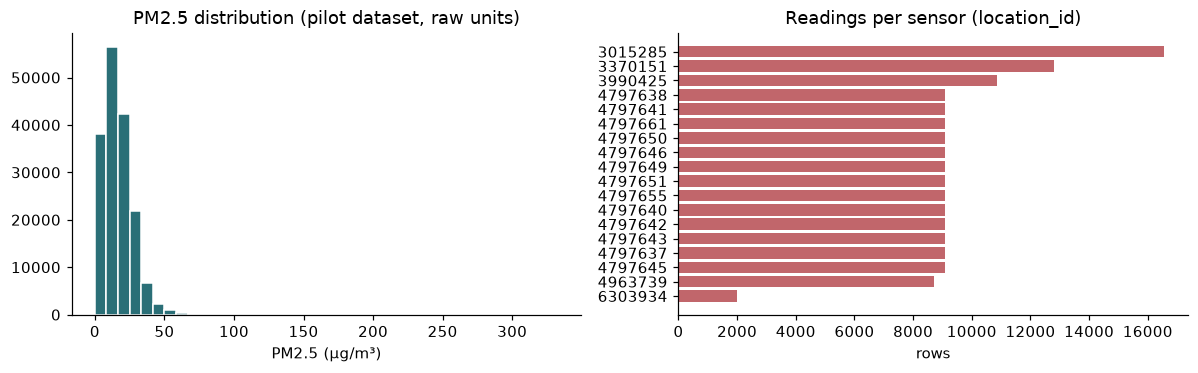

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].hist(modeling_df["pm25_target"], bins=40, color="#2a6f77", edgecolor="white")
axes[0].set_title("PM2.5 distribution (pilot dataset, raw units)")
axes[0].set_xlabel("PM2.5 (\u00b5g/m\u00b3)")

rows_per_sensor = modeling_df["location_id"].value_counts().sort_values()
axes[1].barh(rows_per_sensor.index.astype(str), rows_per_sensor.values, color="#c1666b")
axes[1].set_title("Readings per sensor (location_id)")
axes[1].set_xlabel("rows")

plt.tight_layout()
plt.show()

## 3. Spatial Fold Assignment
Per Section 4.4.1's CNN-LSTM-specific strategy, folds are assigned by **grouping entire sensors together** via `GroupKFold` on `location_id` -- not by K-Means clustering grid-cell centroids, which is the XGBoost side's approach. The scatter plot below shows which sensors land in which fold for a representative 3-fold split.

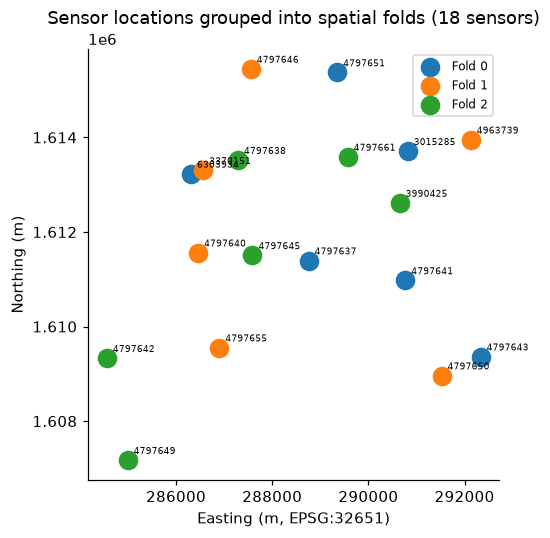

In [17]:
demo_gkf = GroupKFold(n_splits=3)
demo_groups = modeling_df["location_id"].values

sensor_fold_map = {}
for fold_idx, (_, val_pos) in enumerate(demo_gkf.split(modeling_df, groups=demo_groups)):
    for sensor_id in modeling_df.iloc[val_pos]["location_id"].unique():
        sensor_fold_map[sensor_id] = fold_idx

fold_plot_gdf = valid_sensors_gdf.copy()
fold_plot_gdf["fold"] = fold_plot_gdf["location_id"].map(sensor_fold_map)

plt.figure(figsize=(5, 5))
for f in sorted(fold_plot_gdf["fold"].dropna().unique()):
    sub = fold_plot_gdf[fold_plot_gdf["fold"] == f]
    plt.scatter(sub.geometry.x, sub.geometry.y, s=140, label=f"Fold {int(f)}")
for _, r in fold_plot_gdf.iterrows():
    plt.annotate(str(r["location_id"]), (r.geometry.x, r.geometry.y), fontsize=6,
                 xytext=(4, 4), textcoords="offset points")
plt.title(f"Sensor locations grouped into spatial folds ({len(sensor_fold_map)} sensors)")
plt.xlabel("Easting (m, EPSG:32651)"); plt.ylabel("Northing (m)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Spatial K-Fold Bayesian Hyperparameter Optimization
Implements the dual-branch, end-to-end trainable architecture from Section 4.3.2 (independent CNN spatial encoder + LSTM temporal encoder, late-fused via concatenation, then a dense head) and the spatial k-fold Bayesian hyperparameter search from Section 4.3.3. Model validation/evaluation (Section 4.4) is implemented separately in Section 5 below.

### 4.3.2 Dual-Branch Architecture
`CNNEncoder` (spatial branch) processes the morphology patch — read from the Master GeoTIFF — into a flattened 1D feature vector; `LSTMEncoder` (temporal branch) processes the historical PM2.5 lag sequence and returns its final hidden state. `CNNLSTMModel` late-fuses both 1D vectors via concatenation and maps the result to a scalar prediction through a dense head. Backpropagation is standard PyTorch autograd — gradients from the dense layer bifurcate at the concatenation point and flow into both branches simultaneously (BPTT for the LSTM, standard backprop for the CNN), jointly optimized by Adam.

In [18]:
class CNNEncoder(nn.Module):
    """Spatial branch: encodes a (bands, H, W) morphology patch -- cropped from the Master GeoTIFF,
    never from tabular data -- into a 1D feature vector via stacked Conv2d -> ReLU blocks, followed
    by adaptive average pooling so the encoder accepts any patch size."""

    def __init__(self, in_channels, num_filters=32, kernel_size=3, num_conv_layers=2):
        super().__init__()
        layers = []
        channels = in_channels
        for i in range(num_conv_layers):
            out_channels = num_filters * (2 ** i)
            padding = kernel_size // 2
            layers += [nn.Conv2d(channels, out_channels, kernel_size=kernel_size, padding=padding), nn.ReLU(inplace=False)]
            channels = out_channels
        self.conv_blocks = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.output_dim = channels

    def forward(self, x):
        x = self.conv_blocks(x)
        x = self.pool(x)
        return torch.flatten(x, start_dim=1)


class LSTMEncoder(nn.Module):
    """Temporal branch: processes the historical PM2.5 lag sequence through an LSTM and returns the
    final hidden state as a 1D temporal feature vector, capturing autoregressive pollution momentum."""

    def __init__(self, input_size=1, hidden_size=64, num_layers=1, recurrent_dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size, num_layers=num_layers,
            batch_first=True, dropout=recurrent_dropout if num_layers > 1 else 0.0,
        )
        self.output_dim = hidden_size

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        _, (hidden, _) = self.lstm(x)
        return hidden[-1]  # final layer's hidden state at the last time step


class CNNLSTMModel(nn.Module):
    """Dual-branch CNN-LSTM: independently encodes the spatial morphology patch (CNN) and the
    temporal PM2.5 lag sequence (LSTM), late-fuses both 1D vectors via concatenation, and maps the
    fused representation to a scalar PM2.5 prediction through a dense head."""

    def __init__(self, in_channels, lstm_input_size=1, cnn_filters=32, cnn_kernel_size=3,
                 cnn_layers=2, lstm_hidden_size=64, lstm_layers=1, recurrent_dropout=0.0,
                 dense_hidden_size=32):
        super().__init__()
        self.cnn_encoder = CNNEncoder(in_channels, cnn_filters, cnn_kernel_size, cnn_layers)
        self.lstm_encoder = LSTMEncoder(lstm_input_size, lstm_hidden_size, lstm_layers, recurrent_dropout)

        fused_dim = self.cnn_encoder.output_dim + self.lstm_encoder.output_dim
        self.dense_head = nn.Sequential(
            nn.Linear(fused_dim, dense_hidden_size),
            nn.ReLU(inplace=True),
            nn.Linear(dense_hidden_size, 1),
        )

    def forward(self, spatial_patch, temporal_sequence):
        spatial_vector = self.cnn_encoder(spatial_patch)
        temporal_vector = self.lstm_encoder(temporal_sequence)
        fused = torch.cat([spatial_vector, temporal_vector], dim=1)
        return self.dense_head(fused).squeeze(-1)

### Spatial K-Fold Split
Groups sequences by sensor `location_id` so that an entire sensor's history is held out together for validation/testing (Section 4.4.1's CNN-LSTM strategy), rather than randomly shuffling individual rows.

In [19]:
def spatial_group_kfold_split(samples_df, group_col="location_id", n_splits=5):
    """Yields positional (train_idx, test_idx) pairs via GroupKFold, grouping by sensor location so
    an entire sensor's sequences are held out together (spatial k-fold cross-validation)."""
    groups = samples_df[group_col].values
    gkf = GroupKFold(n_splits=n_splits)
    return list(gkf.split(samples_df, groups=groups))


def build_scaled_cnn_lstm_dataset(df_slice, scaler, master_raster_path, lag_cols, target_col,
                                   x_col="x_coordinate", y_col="y_coordinate",
                                   timestamp_col="local_timestamp", group_col="location_id",
                                   sequence_length=None):
    """Apply an already-fitted target scaler to `df_slice` and wrap it in a CNNLSTMDataset. Shared by
    the Bayesian hyperparameter search and the spatial k-fold evaluation loop below."""
    sequence_length = sequence_length or len(lag_cols)
    scaled = df_slice.copy()
    scaled[f"{target_col}_scaled"] = scaler.transform(scaled[[target_col]])
    return CNNLSTMDataset(
        scaled, master_raster_path, lag_cols, target_col=f"{target_col}_scaled",
        x_col=x_col, y_col=y_col, timestamp_col=timestamp_col, group_col=group_col,
        sequence_length=sequence_length,
    )

### Training Loop
Standard supervised training loop (Adam + MSE loss) for one hyperparameter configuration; `train_cnn_lstm` returns the best validation loss achieved, which becomes the Bayesian-optimization objective below.

In [20]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for spatial, temporal, target in dataloader:
        spatial, temporal, target = spatial.to(device), temporal.to(device), target.to(device)
        optimizer.zero_grad()
        prediction = model(spatial, temporal)
        loss = criterion(prediction, target)
        loss.backward()  # BPTT through the LSTM branch, standard backprop through the CNN branch
        optimizer.step()
        total_loss += loss.item() * target.size(0)
    return total_loss / len(dataloader.dataset)


@torch.no_grad()
def evaluate_loss(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    for spatial, temporal, target in dataloader:
        spatial, temporal, target = spatial.to(device), temporal.to(device), target.to(device)
        prediction = model(spatial, temporal)
        loss = criterion(prediction, target)
        total_loss += loss.item() * target.size(0)
    return total_loss / len(dataloader.dataset)


def train_cnn_lstm(train_dataset, val_dataset, hyperparams, in_channels, device=None, verbose=False):
    """Instantiate, train, and validate a CNNLSTMModel for one hyperparameter configuration.
    Returns (best_val_loss, trained_model); best_val_loss is used as the Bayesian-optimization objective."""
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    # skopt's Integer/Real dimensions hand back numpy scalars (e.g. np.int64), but torch.nn.LSTM and
    # DataLoader strictly require native Python int/float, so cast defensively here.
    model = CNNLSTMModel(
        in_channels=in_channels,
        lstm_input_size=1,
        cnn_filters=int(hyperparams["cnn_filters"]),
        cnn_kernel_size=int(hyperparams["cnn_kernel_size"]),
        cnn_layers=int(hyperparams.get("cnn_layers", 2)),
        lstm_hidden_size=int(hyperparams["lstm_hidden_size"]),
        lstm_layers=int(hyperparams.get("lstm_layers", 1)),
        recurrent_dropout=float(hyperparams["recurrent_dropout"]),
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=float(hyperparams["learning_rate"]))
    criterion = nn.MSELoss()

    batch_size = int(hyperparams["batch_size"])
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    epochs = int(hyperparams["epochs"])
    best_val_loss = float("inf")
    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = evaluate_loss(model, val_loader, criterion, device)
        best_val_loss = min(best_val_loss, val_loss)
        if verbose:
            print(f"  Epoch {epoch + 1}/{epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    return best_val_loss, model

### 4.3.3 Optimization Strategy — Spatial K-Fold Bayesian Hyperparameter Search
The search space is categorized by operational role: global training parameters (learning rate, batch size), CNN-specific spatial parameters (kernel size, number of filters), and LSTM-specific temporal parameters (hidden/state size, recurrent dropout). A single level of spatial k-fold cross-validation (grouped by sensor location) guides a Gaussian-process surrogate (`skopt.gp_minimize`), using mean cross-validated loss as the objective an acquisition function minimizes to propose the next candidate. The winning configuration is handed off to Section 4.4, which performs its own independent spatial k-fold evaluation on a fresh split — so hyperparameter selection and final evaluation never reuse the same fold assignment.

In [21]:
# Hyperparameter search space, categorized by operational role (Section 4.3.2):
# global training parameters, CNN-specific spatial parameters, and LSTM-specific temporal parameters.
SEARCH_SPACE = [
    Real(1e-4, 1e-2, prior="log-uniform", name="learning_rate"),   # global
    Integer(16, 128, name="batch_size"),                           # global
    Integer(3, 6, name="cnn_kernel_size"),                         # CNN (spatial)
    Integer(8, 64, name="cnn_filters"),                            # CNN (spatial)
    Integer(16, 128, name="lstm_hidden_size"),                     # LSTM (temporal)
    Real(0.0, 0.5, name="recurrent_dropout"),                      # LSTM (temporal)
]


def bayesian_hyperparameter_search(samples_df, master_raster_path, lag_cols, in_channels,
                                    target_col="pm25_target", group_col="location_id",
                                    x_col="x_coordinate", y_col="y_coordinate", timestamp_col="local_timestamp",
                                    n_splits=3, n_calls=20, n_initial_points=10,
                                    fixed_epochs=15, random_state=42):
    """Spatial k-fold Bayesian hyperparameter optimization for the CNN-LSTM model (Section 4.3.3).

    A single level of spatial k-fold CV, grouped by sensor location, guides a Gaussian-process
    surrogate (`skopt.gp_minimize`) over the hyperparameter space, using mean cross-validated
    validation loss as the objective the acquisition function minimizes. Returns the winning
    hyperparameter dict; Section 4.4 performs the actual held-out evaluation on an independent split,
    so hyperparameter selection and final evaluation never reuse the same fold assignment.
    """
    sequence_length = len(lag_cols)
    splits = spatial_group_kfold_split(samples_df, group_col, n_splits)

    @use_named_args(SEARCH_SPACE)
    def objective(**hyperparams):
        hyperparams = dict(hyperparams, epochs=fixed_epochs, cnn_layers=2, lstm_layers=1)
        fold_losses = []
        for train_pos, val_pos in splits:
            train_df = samples_df.iloc[train_pos]
            val_df = samples_df.iloc[val_pos]

            _, scaler = scale_target_standard(train_df, target_col=target_col)
            train_dataset = build_scaled_cnn_lstm_dataset(
                train_df, scaler, master_raster_path, lag_cols, target_col,
                x_col, y_col, timestamp_col, group_col, sequence_length,
            )
            val_dataset = build_scaled_cnn_lstm_dataset(
                val_df, scaler, master_raster_path, lag_cols, target_col,
                x_col, y_col, timestamp_col, group_col, sequence_length,
            )

            val_loss, _ = train_cnn_lstm(train_dataset, val_dataset, hyperparams, in_channels)
            fold_losses.append(val_loss)
        return float(np.mean(fold_losses))

    search_result = gp_minimize(
        objective, SEARCH_SPACE, n_calls=n_calls, n_initial_points=n_initial_points,
        random_state=random_state,
    )
    best_hyperparams = {dim.name: val for dim, val in zip(SEARCH_SPACE, search_result.x)}
    best_hyperparams.update(epochs=fixed_epochs, cnn_layers=2, lstm_layers=1)

    print(f"Best hyperparameters found: {best_hyperparams} | mean CV loss: {search_result.fun:.4f}")
    return best_hyperparams

### Smoke-Test Execution
A minimal run (few epochs, few Bayesian iterations, 2 outer/2 inner folds, first 50 hourly rows per sensor) against the real pilot data, just to confirm the full nested-CV + Bayesian-search wiring executes correctly end-to-end. Scale up `n_calls`, `fixed_epochs`, fold counts, and drop the per-sensor row cap for an actual production run.

In [22]:
# Keep the smoke test fast: cap each sensor's history to its first 50 hourly rows
smoke_test_df = modeling_df.groupby("location_id").head(50).reset_index(drop=True)
print(f"Smoke-test frame: {smoke_test_df.shape} across {smoke_test_df['location_id'].nunique()} sensors")

best_hyperparams = bayesian_hyperparameter_search(
    samples_df=smoke_test_df,
    master_raster_path=master_tif_path,
    lag_cols=LAG_COLS,
    in_channels=in_channels,
    n_splits=2,
    n_calls=10,
    n_initial_points=5,
    fixed_epochs=2,
)

print(f"Best hyperparameters: {best_hyperparams}")

Smoke-test frame: (900, 14) across 18 sensors
Best hyperparameters found: {'learning_rate': 0.004765526987679208, 'batch_size': np.int64(23), 'cnn_kernel_size': np.int64(5), 'cnn_filters': np.int64(43), 'lstm_hidden_size': np.int64(72), 'recurrent_dropout': 0.007618370112512381, 'epochs': 2, 'cnn_layers': 2, 'lstm_layers': 1} | mean CV loss: 0.4473
Best hyperparameters: {'learning_rate': 0.004765526987679208, 'batch_size': np.int64(23), 'cnn_kernel_size': np.int64(5), 'cnn_filters': np.int64(43), 'lstm_hidden_size': np.int64(72), 'recurrent_dropout': 0.007618370112512381, 'epochs': 2, 'cnn_layers': 2, 'lstm_layers': 1}


---
## 5. CV Results & Spatial Bias Detection
Implements the CNN-LSTM side of the evaluation framework: Section 4.4.1's spatial k-fold CV (grouped by sensor location, entire sensors held out per fold), Section 4.4.2's RMSE/MAE/R² performance quantification (with results plots below), and Section 4.4.3's spatial bias detection (Global/Local Moran's I on aggregated residuals, with a LISA cluster map). The XGBoost k-means-cluster variant of 4.4.1 is out of scope.

### 4.4.1 Spatial K-Fold Cross-Validation Setup (CNN-LSTM)
`spatial_kfold_cv_evaluate` reuses `spatial_group_kfold_split` (already defined above) to hold out contiguous sensor sequences per fold, trains a fresh model on each fold with the given hyperparameters, and collects out-of-fold predictions/residuals with their coordinates for the metrics and bias-detection steps below. `predict_dataset` runs a trained model over a dataset in eval mode.

In [23]:
@torch.no_grad()
def predict_dataset(model, dataset, batch_size=64, device=None):
    """Run a trained model over an entire dataset in eval mode, returning predictions in the same
    (scaled) units the model was trained on."""
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    predictions = []
    for spatial, temporal, _ in loader:
        spatial, temporal = spatial.to(device), temporal.to(device)
        predictions.append(model(spatial, temporal).cpu().numpy())
    return np.concatenate(predictions)


def spatial_kfold_cv_evaluate(samples_df, master_raster_path, lag_cols, in_channels, hyperparams,
                               target_col="pm25_target", group_col="location_id",
                               x_col="x_coordinate", y_col="y_coordinate", timestamp_col="local_timestamp",
                               n_splits=5, verbose=True):
    """Section 4.4.1 spatial k-fold CV for the CNN-LSTM: each fold holds an entire sensor's history
    out entirely. Out-of-fold predictions, residuals, and coordinates across all folds are collected
    for Section 4.4.2 performance metrics and Section 4.4.3 spatial bias detection.

    `hyperparams` is a single fixed configuration (e.g. the winner from `bayesian_hyperparameter_search`)
    — this function evaluates it, it does not search for it.
    """
    sequence_length = len(lag_cols)
    splits = spatial_group_kfold_split(samples_df, group_col, n_splits)

    oof_records = []
    for fold, (train_pos, test_pos) in enumerate(splits):
        train_df = samples_df.iloc[train_pos].reset_index(drop=True)
        test_df = samples_df.iloc[test_pos].reset_index(drop=True)
        print(f"=== Fold {fold + 1}/{n_splits}: train sensors={train_df[group_col].nunique()} | test sensors={test_df[group_col].nunique()} ===")

        _, scaler = scale_target_standard(train_df, target_col=target_col)
        train_dataset = build_scaled_cnn_lstm_dataset(
            train_df, scaler, master_raster_path, lag_cols, target_col,
            x_col, y_col, timestamp_col, group_col, sequence_length,
        )
        test_dataset = build_scaled_cnn_lstm_dataset(
            test_df, scaler, master_raster_path, lag_cols, target_col,
            x_col, y_col, timestamp_col, group_col, sequence_length,
        )

        _, model = train_cnn_lstm(train_dataset, test_dataset, hyperparams, in_channels, verbose=verbose)

        preds_scaled = predict_dataset(model, test_dataset)
        preds = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).ravel()
        actual = test_dataset.samples[target_col].to_numpy()

        fold_records = test_dataset.samples[[group_col, x_col, y_col, timestamp_col]].copy()
        fold_records["y_true"] = actual
        fold_records["y_pred"] = preds
        fold_records["residual"] = fold_records["y_true"] - fold_records["y_pred"]
        fold_records["fold"] = fold
        oof_records.append(fold_records)

    return pd.concat(oof_records, ignore_index=True)

### 4.4.2 Performance Quantification
RMSE (penalizes large errors / PM2.5 spikes), MAE (interpretable average error magnitude), and R² (variance explained beyond a constant baseline) computed on out-of-fold predictions, both overall and per fold.

In [24]:
def evaluate_predictions(y_true, y_pred):
    """RMSE, MAE, and R^2 for a set of predictions (Section 4.4.2)."""
    return {
        "rmse": root_mean_squared_error(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }


def summarize_oof_metrics(oof_df, per_fold=True):
    """Overall RMSE/MAE/R^2 on all out-of-fold predictions, plus a per-fold breakdown to spot folds
    (e.g. sensors in unusual environments) the model struggles with disproportionately."""
    overall = evaluate_predictions(oof_df["y_true"], oof_df["y_pred"])
    print(f"Overall — RMSE={overall['rmse']:.3f} | MAE={overall['mae']:.3f} | R2={overall['r2']:.3f}")

    if per_fold:
        for fold, group in oof_df.groupby("fold"):
            fold_metrics = evaluate_predictions(group["y_true"], group["y_pred"])
            print(f"  Fold {fold} — RMSE={fold_metrics['rmse']:.3f} | MAE={fold_metrics['mae']:.3f} | R2={fold_metrics['r2']:.3f}")
    return overall

### Spatial Bias Detection (Section 4.4.3)
Aggregates out-of-fold residuals to their grid cell, builds a K-Nearest-Neighbors spatial weights matrix, and tests Global Moran's I for statistically significant spatial autocorrelation in the errors. If significant, Local Moran's I (LISA) decomposes it into per-cell High-High (systematic underprediction hotspots) / Low-Low (systematic overprediction coldspots) / High-Low / Low-High clusters, rendered as a LISA cluster map overlaid on the grid cells.

In [25]:
def load_grid_from_csv(csv_path, crs=TARGET_CRS):
    """Rebuild the grid GeoDataFrame (grid_id + cell geometry) from the exported morphology grid CSV
    (e.g. `full_morphology_grid.csv`), so residuals can be joined back to their spatial cell."""
    df = pd.read_csv(csv_path).rename(columns={"id": "grid_id"})
    geometries = [box(row.left, row.bottom, row.right, row.top) for row in df.itertuples()]
    return gpd.GeoDataFrame(df, geometry=geometries, crs=crs)


def aggregate_residuals_by_grid(oof_df, sensor_grid_map, group_col="location_id"):
    """Aggregate out-of-fold residuals to their geographic grid cell (Section 4.4.3, step 1)."""
    merged = oof_df.merge(sensor_grid_map, on=group_col, how="left")
    return merged.groupby("grid_id")["residual"].mean().reset_index()


def build_knn_spatial_weights(grid_gdf, residual_grid_df, k=5):
    """K-Nearest-Neighbors spatial weights matrix over the grid cells that have residual observations,
    row-standardized as is conventional for Moran's I."""
    cells = grid_gdf.merge(residual_grid_df, on="grid_id", how="inner").reset_index(drop=True)
    weights = KNN.from_dataframe(cells, k=k)
    weights.transform = "r"
    return cells, weights


def compute_global_morans_i(cells, weights, value_col="residual", permutations=999):
    """Global Moran's I: tests whether residual errors are randomly distributed geographically or
    systematically cluster (e.g. hotspots of over/underprediction)."""
    moran = Moran(cells[value_col].values, weights, permutations=permutations)
    return {"I": moran.I, "p_sim": moran.p_sim, "z_sim": moran.z_sim}


def compute_local_morans_i(cells, weights, value_col="residual", permutations=999, significance=0.05):
    """Anselin's Local Moran's I (LISA): decomposes the global metric into per-cell High-High /
    Low-High / Low-Low / High-Low spatial clusters of residuals, for overlay onto the morphology maps."""
    lisa = Moran_Local(cells[value_col].values, weights, permutations=permutations)
    quadrant_labels = {1: "High-High", 2: "Low-High", 3: "Low-Low", 4: "High-Low"}

    result = cells.copy()
    result["lisa_I"] = lisa.Is
    result["lisa_p"] = lisa.p_sim
    result["lisa_cluster"] = np.where(
        result["lisa_p"] < significance, pd.Series(lisa.q, index=result.index).map(quadrant_labels), "Not Significant",
    )
    return result


def detect_spatial_bias(oof_df, grid_gdf, sensor_grid_map, k=5, significance=0.05, permutations=999, plot=True):
    """Section 4.4.3 end-to-end: aggregate residuals by grid cell, build KNN spatial weights, render a
    residual heatmap of the results, test Global Moran's I, and -- only if significant -- decompose it
    into Local Moran's I / LISA clusters, rendered as a LISA cluster map."""
    residual_grid_df = aggregate_residuals_by_grid(oof_df, sensor_grid_map)
    cells, weights = build_knn_spatial_weights(grid_gdf, residual_grid_df, k=k)

    if plot:
        plot_residual_map(cells)

    global_result = compute_global_morans_i(cells, weights, permutations=permutations)
    print(f"Global Moran's I = {global_result['I']:.4f} | p_sim = {global_result['p_sim']:.4f}")

    if global_result["p_sim"] < significance:
        print("Statistically significant global spatial autocorrelation detected — running Local Moran's I (LISA).")
        lisa_result = compute_local_morans_i(cells, weights, permutations=permutations, significance=significance)
        print(lisa_result["lisa_cluster"].value_counts())
        if plot:
            plot_lisa_clusters(lisa_result)
        return global_result, lisa_result

    print("No statistically significant global spatial autocorrelation detected.")
    return global_result, None

### LISA Cluster Map
Section 4.4.3 calls for "LISA maps, which categorize the localized residuals into specific spatial clusters" and for overlaying them "onto the multi-band morphology feature maps" — `plot_lisa_clusters` renders that map (High-High / Low-Low / High-Low / Low-High / Not Significant), drawn only when Global Moran's I is significant.

In [26]:
from matplotlib.colors import TwoSlopeNorm

LISA_CLUSTER_COLORS = {
    "High-High": "#d7191c",
    "Low-Low": "#2c7bb6",
    "Low-High": "#abd9e9",
    "High-Low": "#fdae61",
    "Not Significant": "#d9d9d9",
}


def plot_residual_map(cells, value_col="residual", title="Mean Residual by Grid Cell (Section 4.4.3)"):
    """Heatmap of the model's out-of-fold results: mean PM2.5 residual per grid cell on a diverging
    color scale (red = underprediction, blue = overprediction) -- a first, non-statistical look at
    whether the model's errors cluster geographically, drawn before the formal Moran's I test."""
    fig, ax = plt.subplots(figsize=(8, 8))
    vmax = max(cells[value_col].abs().max(), 1e-6)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    cells.plot(column=value_col, cmap="RdBu_r", norm=norm, legend=True,
               edgecolor="grey", linewidth=0.3, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()
    return fig


def plot_lisa_clusters(lisa_result, cluster_col="lisa_cluster", title="LISA Cluster Map (Section 4.4.3)"):
    """Map of grid cells colored by their Local Moran's I cluster category -- the standard LISA map
    used to spot High-High (systematic underprediction) / Low-Low (systematic overprediction) hotspots."""
    fig, ax = plt.subplots(figsize=(8, 8))
    for cluster, color in LISA_CLUSTER_COLORS.items():
        subset = lisa_result[lisa_result[cluster_col] == cluster]
        if len(subset):
            subset.plot(ax=ax, color=color, edgecolor="grey", linewidth=0.3, label=cluster)
    ax.set_title(title)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal")

    legend_handles = [mpatches.Patch(color=c, label=l) for l, c in LISA_CLUSTER_COLORS.items()]
    ax.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.02, 1), title="Cluster")
    plt.tight_layout()
    plt.show()
    return fig

### Smoke-Test Execution
A minimal run (2 epochs, 3 evaluation folds, first 300 hourly rows per sensor) against the real pilot data, confirming the spatial CV + metrics + Moran's I wiring executes correctly end-to-end. Scale up epochs, folds, and drop the per-sensor row cap for an actual production run.

In [27]:
eval_df = modeling_df.groupby("location_id").head(300).reset_index(drop=True)
print(f"Evaluation frame: {eval_df.shape} across {eval_df['location_id'].nunique()} sensors")

eval_hyperparams = {
    "learning_rate": 0.001, "batch_size": 32, "cnn_kernel_size": 3, "cnn_filters": 16,
    "lstm_hidden_size": 32, "recurrent_dropout": 0.1, "epochs": 5, "cnn_layers": 2, "lstm_layers": 1,
}

oof_df = spatial_kfold_cv_evaluate(
    samples_df=eval_df,
    master_raster_path=master_tif_path,
    lag_cols=LAG_COLS,
    in_channels=in_channels,
    hyperparams=eval_hyperparams,
    n_splits=3,
)

overall_metrics = summarize_oof_metrics(oof_df)

Evaluation frame: (5400, 14) across 18 sensors
=== Fold 1/3: train sensors=12 | test sensors=6 ===
  Epoch 1/5 | train_loss=0.5550 | val_loss=0.2672
  Epoch 2/5 | train_loss=0.3107 | val_loss=0.2545
  Epoch 3/5 | train_loss=0.3009 | val_loss=0.2400
  Epoch 4/5 | train_loss=0.2868 | val_loss=0.2355
  Epoch 5/5 | train_loss=0.2852 | val_loss=0.2763
=== Fold 2/3: train sensors=12 | test sensors=6 ===
  Epoch 1/5 | train_loss=0.5334 | val_loss=0.3110
  Epoch 2/5 | train_loss=0.2665 | val_loss=0.2953
  Epoch 3/5 | train_loss=0.2506 | val_loss=0.2774
  Epoch 4/5 | train_loss=0.2390 | val_loss=0.2773
  Epoch 5/5 | train_loss=0.2418 | val_loss=0.2766
=== Fold 3/3: train sensors=12 | test sensors=6 ===
  Epoch 1/5 | train_loss=0.6278 | val_loss=0.3552
  Epoch 2/5 | train_loss=0.3030 | val_loss=0.3037
  Epoch 3/5 | train_loss=0.2900 | val_loss=0.2926
  Epoch 4/5 | train_loss=0.2797 | val_loss=0.2877
  Epoch 5/5 | train_loss=0.2762 | val_loss=0.2866
Overall — RMSE=5.365 | MAE=3.549 | R2=0.721
  F

#### Results Visualization
RMSE/R² by fold plus an actual-vs-predicted scatter across all out-of-fold predictions, mirroring the equivalent results plots on the XGBoost side.

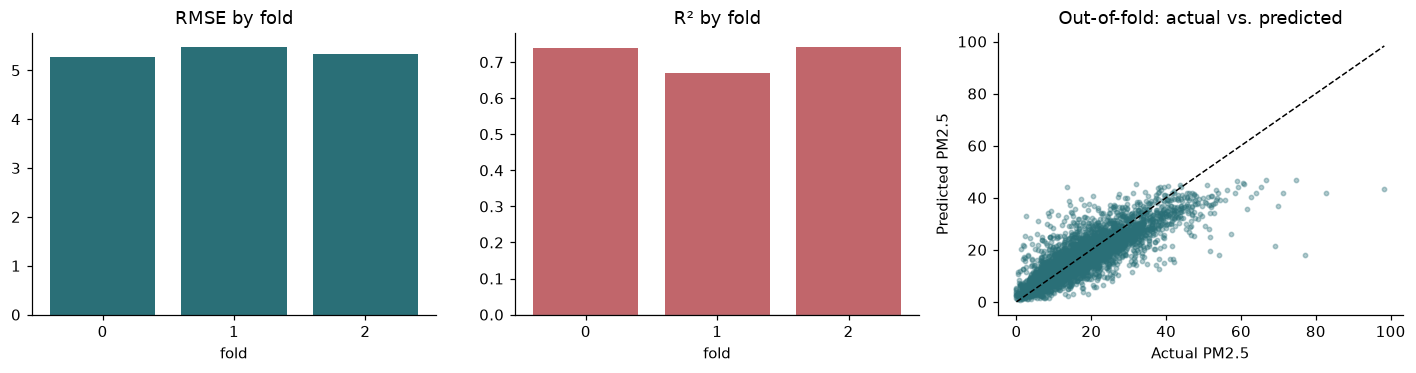

In [28]:
fold_summary = oof_df.groupby("fold").apply(
    lambda g: pd.Series(evaluate_predictions(g["y_true"], g["y_pred"]))
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

axes[0].bar(fold_summary["fold"].astype(str), fold_summary["rmse"], color="#2a6f77")
axes[0].set_title("RMSE by fold"); axes[0].set_xlabel("fold")

axes[1].bar(fold_summary["fold"].astype(str), fold_summary["r2"], color="#c1666b")
axes[1].set_title("R\u00b2 by fold"); axes[1].set_xlabel("fold")
axes[1].axhline(0, color="gray", linewidth=0.8)

axes[2].scatter(oof_df["y_true"], oof_df["y_pred"], s=8, alpha=0.35, color="#2a6f77")
lims = [oof_df[["y_true", "y_pred"]].min().min(), oof_df[["y_true", "y_pred"]].max().max()]
axes[2].plot(lims, lims, "k--", linewidth=1)
axes[2].set_title("Out-of-fold: actual vs. predicted")
axes[2].set_xlabel("Actual PM2.5"); axes[2].set_ylabel("Predicted PM2.5")

plt.tight_layout()
plt.show()

#### Spatial Bias Detection Execution

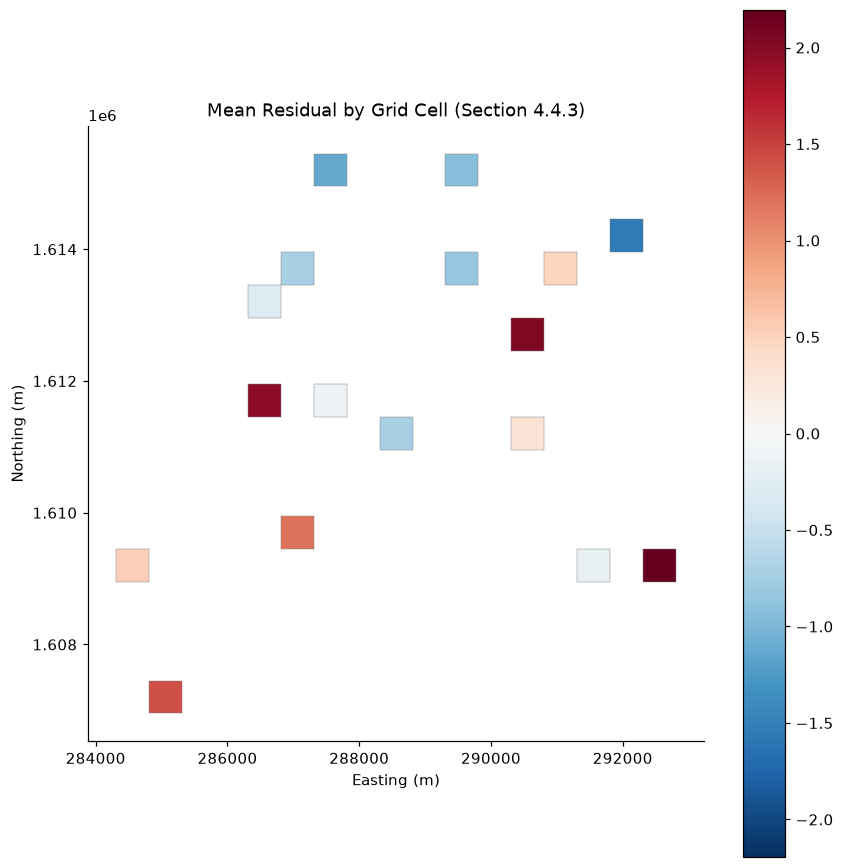

Global Moran's I = 0.0253 | p_sim = 0.2060
No statistically significant global spatial autocorrelation detected.


In [29]:
# map each sensor to its grid cell, then test residuals for spatial autocorrelation
grid_gdf_from_csv = load_grid_from_csv("../full_morphology_grid.csv")
sensor_grid_map = spatial_join_sensors_to_grid(valid_sensors_gdf, grid_gdf_from_csv)[["location_id", "grid_id"]]

global_result, lisa_result = detect_spatial_bias(oof_df, grid_gdf_from_csv, sensor_grid_map, k=5, permutations=999)

---
## 6. Final Production Model
Same approach as the XGBoost side's production step: refit on the full evaluation-scale dataset (no held-out sensors) using the winning hyperparameters, producing a single deployable model. This `production_model` is also what Section 7's Grad-CAM interpretability runs against.

In [30]:
_, production_scaler = scale_target_standard(eval_df, target_col="pm25_target")
production_dataset = build_scaled_cnn_lstm_dataset(
    eval_df, production_scaler, master_tif_path, LAG_COLS, "pm25_target",
    sequence_length=len(LAG_COLS),
)

# No held-out sensors remain, so the "validation" set below is only used for the training loop's
# progress printout -- it plays no role in model selection (that already happened in Section 4/5).
_, production_model = train_cnn_lstm(
    production_dataset, production_dataset, eval_hyperparams, in_channels, verbose=True,
)
print("Production model fit on the full evaluation-scale dataset (no held-out sensors).")

  Epoch 1/5 | train_loss=0.4556 | val_loss=0.3075
  Epoch 2/5 | train_loss=0.2865 | val_loss=0.2709
  Epoch 3/5 | train_loss=0.2738 | val_loss=0.2803
  Epoch 4/5 | train_loss=0.2674 | val_loss=0.2681
  Epoch 5/5 | train_loss=0.2670 | val_loss=0.2609
Production model fit on the full evaluation-scale dataset (no held-out sensors).


---
## 7. Model Interpretability via Grad-CAM (Section 4.5.4)
Section 4.5.4 assigns SHAP to XGBoost (tabular feature attribution) and **Grad-CAM to CNN-LSTM** specifically, since the CNN branch's input is a spatial image patch, not a flat feature vector. `GradCAM` hooks the last `Conv2d` layer inside `CNNEncoder.conv_blocks`, backpropagates from the model's scalar PM2.5 prediction, and combines the resulting gradients with that layer's activations into a spatial saliency map -- showing which regions of the input patch most influenced the prediction.

**Caveat:** the pilot Master GeoTIFF is a 500m-resolution placeholder, so today's patch is a single pixel and the resulting "heatmap" is correspondingly 1x1 -- mechanically correct, but not visually informative until the production 10m raster (and its 32x32 pixel patches) replaces it.

In [31]:
class GradCAM:
    """Grad-CAM for the CNN branch: hooks the last Conv2d layer inside CNNEncoder.conv_blocks,
    captures its forward activations and the gradient of the model's scalar output with respect to
    them, and combines the two into a spatial importance heatmap over the input patch -- the
    CNN-LSTM's counterpart to the XGBoost side's SHAP interpretability (Section 4.5.4)."""

    def __init__(self, model):
        self.model = model
        self.activations = None
        self.gradients = None

        target_layer = [m for m in model.cnn_encoder.conv_blocks if isinstance(m, nn.Conv2d)][-1]
        target_layer.register_forward_hook(self._save_activations)
        target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, module, input, output):
        self.activations = output.detach()

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, spatial_patch, temporal_sequence):
        """spatial_patch: (1, bands, H, W); temporal_sequence: (1, seq_len, 1). Returns a (H, W)
        heatmap in [0, 1] showing which patch regions most influenced the predicted PM2.5 value,
        alongside the raw prediction."""
        self.model.zero_grad()
        prediction = self.model(spatial_patch, temporal_sequence)
        prediction.sum().backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # global-average-pooled gradients
        cam = torch.relu((weights * self.activations).sum(dim=1)).squeeze(0)

        if cam.max() > 0:
            cam = cam / cam.max()
        return cam.cpu().numpy(), prediction.item()


def plot_gradcam_overlay(spatial_patch, cam, band_index=0, title="Grad-CAM: CNN Spatial Attention"):
    """Overlay the Grad-CAM heatmap on one band of the input patch (band 0 = mean building height)."""
    patch_band = spatial_patch.squeeze(0)[band_index].cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].imshow(patch_band, cmap="viridis")
    axes[0].set_title(f"Input patch (band {band_index})")
    axes[1].imshow(patch_band, cmap="gray")
    axes[1].imshow(cam, cmap="jet", alpha=0.5)
    axes[1].set_title(title)
    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()
    return fig

### Grad-CAM Demo
Runs Grad-CAM on one sample from the production dataset.

Predicted (scaled) PM2.5 for this sample: -1.0203 | Grad-CAM heatmap shape: (32, 32)


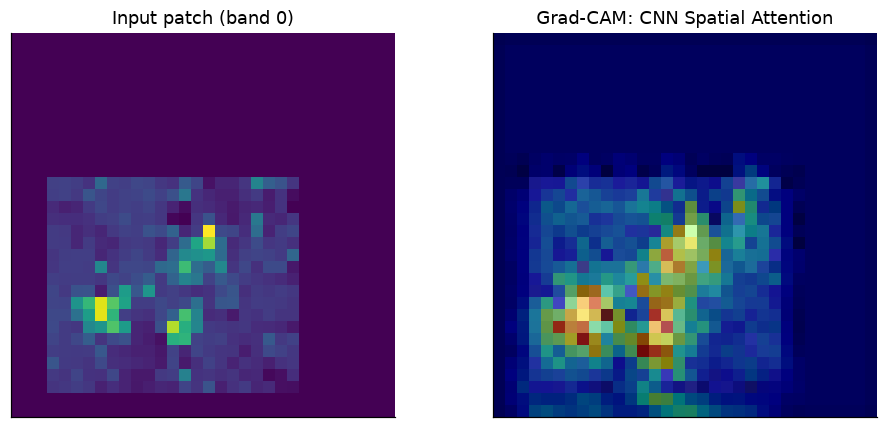

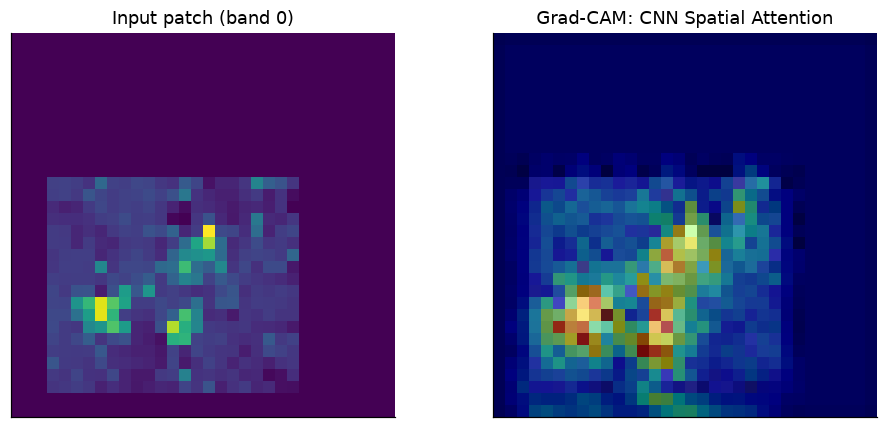

In [32]:
production_model.eval()
gradcam = GradCAM(production_model)

sample_spatial, sample_temporal, sample_target = production_dataset[0]
cam, prediction = gradcam.generate(sample_spatial.unsqueeze(0), sample_temporal.unsqueeze(0))

print(f"Predicted (scaled) PM2.5 for this sample: {prediction:.4f} | Grad-CAM heatmap shape: {cam.shape}")
plot_gradcam_overlay(sample_spatial.unsqueeze(0), cam)

---
## 8. Summary

- **18 sensors** (after spatial + data-quality filtering) feed this CNN-LSTM pilot, the same set that underlies the XGBoost side's comparison run.
- **Spatial k-fold CV** groups by sensor `location_id` (Section 4.4.1's CNN-LSTM-specific strategy), rather than K-Means clustering grid-cell centroids as the XGBoost side does — the two architectures deliberately use different fold-assignment logic per the thesis methodology.
- **The CNN branch is currently spatially uninformative**: the pilot Master GeoTIFF is a 500m-resolution placeholder, so a 320m patch collapses to a single pixel. RMSE/MAE/R² here mostly reflect the LSTM branch's temporal signal; the Grad-CAM heatmap above is correspondingly a single-pixel "map" until the real 10m raster replaces it.
- **Grad-CAM, not SHAP, is used for CNN-LSTM interpretability** (Section 4.5.4 assigns SHAP to XGBoost and Grad-CAM to CNN-LSTM specifically) — it attributes the prediction to spatial regions of the input patch rather than to tabular feature columns.
- **A Final Production Model** is fit on the full evaluation-scale dataset (no held-out sensors) using the winning hyperparameters, matching the XGBoost side's "fit on everything, once tuning is done" step.
- Compare this pipeline's `summarize_oof_metrics` output against the XGBoost notebook's `results_df` directly — both now run on the same 18-sensor pilot data.